# Modules

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

from longitudinal_arm_swing.constants import *

pd.set_option('display.max_columns', 500)

# Constants

In [ ]:
segment_lengths = ['0_20', '20_inf']
filter_type = 'filtered'
measures = ['median', '95p', 'median_cov']

path_measures = BASE_PATH / 'measures' / f'{filter_type}_gait'
path_figures_paper = r'C:\Users\z665206\Documents\PhD\docs\papers\ppp\paper\tex\imgs'

pd_med_id_filename = 'pd_med_ids.txt'
pd_no_med_id_filename = 'pd_no_med_ids.txt'
ids_remaining_after_exclusions_filename = 'ids_remaining_after_exclusions.json'
aff_side_ids_filename = 'affected_side_ids.json'

first_week = 2
mid_week = 52
final_week = 100

off_score = 'updrs_3_hypokinesia_off_ws'
on_score = 'updrs_3_hypokinesia_on_ws'

save_plots = True

# Load

In [ ]:
signal_interp_vals = {}
for group in ['pd', 'controls']:
    signal_interp_vals[group] = {}
    for segment_length in segment_lengths:
        signal_interp_vals[group][segment_length] = {}
        for measure in measures:
            signal_interp_vals[group][segment_length][measure] = pd.read_csv(path_measures / segment_length / f'{group}_signal_interp_{measure}_range_of_motion.csv')

df_measures_inclusion = pd.read_parquet(BASE_PATH / 'measures' / 'digital_measures.parquet')

with open(path_measures / '20_inf' / 'pd_med_ids.txt', 'r') as f:
    pd_med_ids = f.read().splitlines()

with open(path_measures / '20_inf' / 'pd_no_med_ids.txt', 'r') as f:
    pd_no_med_ids = f.read().splitlines()

with open(PATH_IDS / ids_remaining_after_exclusions_filename, 'r') as f:
    ids_remaining_after_exclusions = json.load(f)

with open(PATH_IDS / aff_side_ids_filename, 'r') as f:
    aff_side_ids = json.load(f)

with open(PATH_IDS / 'ids_late_visit_3.txt', 'r') as f:
    ids_late_visit3 = f.read().splitlines()

df_clinical = pd.read_parquet(PATH_CLINICAL_DATA / 'clinical_data.parquet')

with open(path_measures / 'delta_scores.json', 'r') as f:
    delta_scores_n_weights = json.load(f)

# Prepare data

### Clinical data

In [4]:
delta_scores = {
    'mas': {},
    'las': {},
}

regr_ids = ids_remaining_after_exclusions['ppp']['regr'] + ids_remaining_after_exclusions['denovo']['regr']

for j, subject in enumerate(regr_ids):
    if subject in aff_side_ids['ppp']['mas'] + aff_side_ids['denovo']['mas']:
        side = 'mas'
    else:
        side = 'las'

    if subject in pd_med_ids:
        med_state = 'med'
    else:
        med_state = 'no_med'

    group = f'pd_{side}'
    
    df_subject_clinical = df_clinical.loc[df_clinical['id']==subject]
    delta_scores[side][subject] = {}
    visits = df_subject_clinical['visit'].unique()

    if subject not in delta_scores_n_weights['0_20'][f'{group}_{med_state}'][measure][f'dynamic_{final_week}']['ids']:
        del delta_scores[side][subject]
        continue

    for segment_length in segment_lengths:
        delta_scores[side][subject][segment_length] = {}
        for measure in measures:
            df_subject_digital = signal_interp_vals['pd'][segment_length][measure].iloc[pd_med_ids.index(subject)]

            delta_scores[side][subject][segment_length][f'{measure}_12'] = df_subject_digital[f'week{mid_week}'] - df_subject_digital[f'week{first_week}']
            delta_scores[side][subject][segment_length][f'{measure}_13'] = df_subject_digital[f'week{final_week}'] - df_subject_digital[f'week{first_week}']
            delta_scores[side][subject][segment_length][f'{measure}_23'] = df_subject_digital[f'week{final_week}'] - df_subject_digital[f'week{mid_week}']

            delta_scores_n_weights_focus = delta_scores_n_weights['0_20'][f'{group}_{med_state}'][measure][f'dynamic_{final_week}']

            subject_idx = delta_scores_n_weights_focus['ids'].index(subject)
            unweighted_vals = delta_scores_n_weights_focus['unweighted'][subject_idx]
            weighted_vals = delta_scores_n_weights_focus['unweighted'][subject_idx] * delta_scores_n_weights_focus['weights'][subject_idx]

            delta_scores[side][subject][segment_length][f'{measure}_13_weighted'] = weighted_vals

    if 1 in visits:
        ledd_1 = df_subject_clinical.loc[df_subject_clinical['visit']==1, 'ledd'].values[0]
        delta_scores[side][subject]['ledd_1'] = ledd_1

        delta_scores[side][subject]['years_since_diagnosis'] = df_subject_clinical.loc[df_subject_clinical['visit']==1, 'YearsSinceDiagFloat'].values[0]
        delta_scores[side][subject]['at_least_slight_dyskinesia_visit_1'] = df_subject_clinical.loc[df_subject_clinical['visit']==1, 'at_least_slight_dyskinesia'].values[0]
        delta_scores[side][subject]['daily_off_state_hrs_visit_1'] = df_subject_clinical.loc[df_subject_clinical['visit']==1, 'MotComDailyOffState'].values[0]

    else:
        delta_scores[side][subject]['ledd_1'] = np.nan

    if 2 in visits:
        ledd_2 = df_subject_clinical.loc[df_subject_clinical['visit']==2, 'ledd'].values[0]
        delta_scores[side][subject]['ledd_2'] = ledd_2
        delta_scores[side][subject]['at_least_slight_dyskinesia_visit_2'] = df_subject_clinical.loc[df_subject_clinical['visit']==2, 'at_least_slight_dyskinesia'].values[0]
        delta_scores[side][subject]['daily_off_state_hrs_visit_2'] = df_subject_clinical.loc[df_subject_clinical['visit']==2, 'MotComDailyOffState'].values[0]
    else:
        delta_scores[side][subject]['ledd_2'] = np.nan

    if 3 in visits:
        ledd_3 = df_subject_clinical.loc[df_subject_clinical['visit']==3, 'ledd'].values[0]
        delta_scores[side][subject]['ledd_3'] = ledd_3
        delta_scores[side][subject]['at_least_slight_dyskinesia_visit_3'] = df_subject_clinical.loc[df_subject_clinical['visit']==3, 'at_least_slight_dyskinesia'].values[0]
        delta_scores[side][subject]['daily_off_state_hrs_visit_3'] = df_subject_clinical.loc[df_subject_clinical['visit']==3, 'MotComDailyOffState'].values[0]
    else:
        delta_scores[side][subject]['ledd_3'] = np.nan

    if pd.isna(ledd_2):
        delta_scores[side][subject]['ledd_1_2'] = np.nan
    elif pd.isna(ledd_1):
        delta_scores[side][subject]['ledd_1_2'] = ledd_2
    else:
        delta_scores[side][subject]['ledd_1_2'] = ledd_2 - ledd_1

    if pd.isna(ledd_3):
        delta_scores[side][subject]['ledd_2_3'] = np.nan
    elif pd.isna(ledd_2):
        delta_scores[side][subject]['ledd_2_3'] = np.nan
    else:
        delta_scores[side][subject]['ledd_2_3'] = ledd_3 - ledd_2

    if pd.isna(ledd_3):
        delta_scores[side][subject]['ledd_1_3'] = np.nan
    elif pd.isna(ledd_1):
        delta_scores[side][subject]['ledd_1_3'] = ledd_3
    else:
        delta_scores[side][subject]['ledd_1_3'] = ledd_3 - ledd_1

    for score in [off_score, on_score, 'updrs_2_total']:
        if all([x in visits for x in [1, 2]]):
            delta_updrs_12 = df_subject_clinical.loc[df_subject_clinical['visit']==2, score].values[0] - df_subject_clinical.loc[df_subject_clinical['visit']==1, score].values[0]
        else:
            delta_updrs_12 = np.nan

        if all([x in visits for x in [1, 3]]):
            delta_updrs_13 = df_subject_clinical.loc[df_subject_clinical['visit']==3, score].values[0] - df_subject_clinical.loc[df_subject_clinical['visit']==1, score].values[0]
        else:
            delta_updrs_13 = np.nan
        
        if all([x in visits for x in [2, 3]]):
            delta_updrs_23 = df_subject_clinical.loc[df_subject_clinical['visit']==3, score].values[0] - df_subject_clinical.loc[df_subject_clinical['visit']==2, score].values[0]
        else:
            delta_updrs_23 = np.nan

        delta_scores[side][subject][f'{score}_12'] = delta_updrs_12
        delta_scores[side][subject][f'{score}_13'] = delta_updrs_13
        delta_scores[side][subject][f'{score}_23'] = delta_updrs_23


# Regression

In [ ]:
measure = 'median_cov'
segment_length = 'short'

dfs = []
for side in ['mas', 'las']:
    ledd_ids = list(delta_scores[side].keys())

    dfs.append(pd.DataFrame({
        'id': ledd_ids,
        'most_affected_side': [1 if x in delta_scores['mas'] else 0 for x in ledd_ids],
        'delta_ledd': [delta_scores[side][x]['ledd_1_3'] for x in ledd_ids],
        'delta_median_short': [delta_scores[side][x]['0_20']['median_13'] for x in ledd_ids],
        'delta_median_long': [delta_scores[side][x]['20_inf']['median_13'] for x in ledd_ids],
        'delta_95p_short': [delta_scores[side][x]['0_20']['95p_13'] for x in ledd_ids],
        'delta_95p_long': [delta_scores[side][x]['20_inf']['95p_13'] for x in ledd_ids],
        'delta_median_cov_short': [delta_scores[side][x]['0_20']['median_cov_13'] for x in ledd_ids],
        'delta_median_cov_long': [delta_scores[side][x]['20_inf']['median_cov_13'] for x in ledd_ids],
        'years_since_diagnosis': [delta_scores[side][x]['years_since_diagnosis'] for x in ledd_ids],
        'delta_dyskinesia': [delta_scores[side][x]['at_least_slight_dyskinesia_visit_3'].astype(int) - 
                             delta_scores[side][x]['at_least_slight_dyskinesia_visit_1'].astype(int) for x in ledd_ids],
    }))

df_ols = pd.concat(dfs)

target_column = f'delta_{measure}_{segment_length}'
covariates = ['most_affected_side', 'delta_ledd', 'years_since_diagnosis', 'delta_dyskinesia'] # 

interaction_covs = []
for cov in covariates:
    if cov != "most_affected_side" and 'baseline' not in cov:
        interaction_cov =f"{cov}_x_most_affected_side"
        df_ols[interaction_cov] = df_ols[cov] * df_ols["most_affected_side"]
        interaction_covs.append(interaction_cov)

nonbinary_covariates = ['delta_ledd', 'years_since_diagnosis', 'delta_dyskinesia']

df_ols_regr = df_ols.dropna(subset=[target_column] + covariates)

y = df_ols_regr[target_column]
X = df_ols_regr[covariates + interaction_covs]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     delta_median_cov_short   R-squared:                       0.111
Model:                                OLS   Adj. R-squared:                  0.089
Method:                     Least Squares   F-statistic:                     5.031
Date:                    Thu, 16 Oct 2025   Prob (F-statistic):           2.16e-05
Time:                            14:45:21   Log-Likelihood:                 589.77
No. Observations:                     289   AIC:                            -1164.
Df Residuals:                         281   BIC:                            -1134.
Df Model:                               7                                         
Covariance Type:                nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

<>:47: SyntaxWarning: invalid escape sequence '\D'
<>:48: SyntaxWarning: invalid escape sequence '\D'
<>:157: SyntaxWarning: invalid escape sequence '\D'
<>:47: SyntaxWarning: invalid escape sequence '\D'
<>:48: SyntaxWarning: invalid escape sequence '\D'
<>:157: SyntaxWarning: invalid escape sequence '\D'
C:\Users\z665206\AppData\Local\Temp\ipykernel_18212\2187407001.py:47: SyntaxWarning: invalid escape sequence '\D'
  'delta_ledd': '$\Delta$ LEDD',
C:\Users\z665206\AppData\Local\Temp\ipykernel_18212\2187407001.py:48: SyntaxWarning: invalid escape sequence '\D'
  'delta_dyskinesia': '$\Delta$ Dyskinesia',
C:\Users\z665206\AppData\Local\Temp\ipykernel_18212\2187407001.py:157: SyntaxWarning: invalid escape sequence '\D'
  ylabel = f'Standardized\n$\Delta$ {AGGREGATION_RENAMING[measure]} RoM'


median - short - delta_ledd MAS: 0.18 (0.05, 0.32), p=0.009
median - short - delta_ledd LAS: 0.10 (-0.09, 0.28), p=0.296
median - short - delta_dyskinesia MAS: 0.20 (0.06, 0.33), p=0.006
median - short - delta_dyskinesia LAS: -0.05 (-0.23, 0.12), p=0.557
median - long - delta_ledd MAS: 0.09 (-0.05, 0.23), p=0.200
median - long - delta_ledd LAS: 0.09 (-0.10, 0.28), p=0.357
median - long - delta_dyskinesia MAS: 0.11 (-0.03, 0.26), p=0.124
median - long - delta_dyskinesia LAS: 0.06 (-0.12, 0.25), p=0.498
95p - short - delta_ledd MAS: 0.14 (0.00, 0.27), p=0.049
95p - short - delta_ledd LAS: 0.06 (-0.13, 0.24), p=0.537
95p - short - delta_dyskinesia MAS: 0.26 (0.12, 0.40), p=0.000
95p - short - delta_dyskinesia LAS: 0.01 (-0.17, 0.19), p=0.920
95p - long - delta_ledd MAS: 0.15 (0.02, 0.29), p=0.029
95p - long - delta_ledd LAS: 0.21 (0.02, 0.40), p=0.029
95p - long - delta_dyskinesia MAS: 0.20 (0.06, 0.34), p=0.004
95p - long - delta_dyskinesia LAS: 0.12 (-0.06, 0.30), p=0.196
median_cov - s

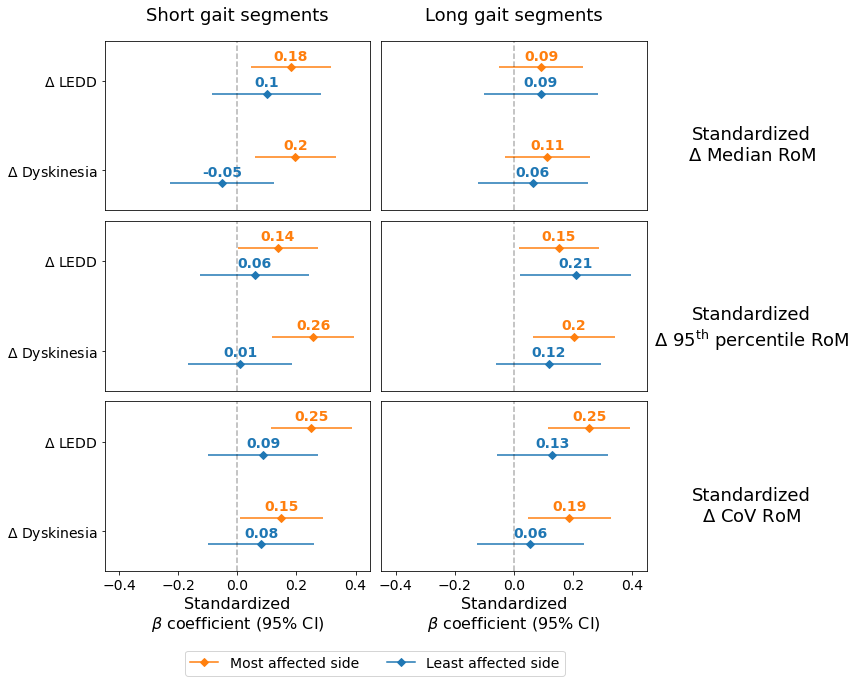

In [ ]:
standardize = True

dfs = []
for side in ['mas', 'las']:
    ledd_ids = list(delta_scores[side].keys())

    dfs.append(pd.DataFrame({
        'id': ledd_ids,
        'most_affected_side': [1 if x in delta_scores['mas'] else 0 for x in ledd_ids],
        'delta_ledd': [delta_scores[side][x]['ledd_1_3'] for x in ledd_ids],
        'delta_median_short': [delta_scores[side][x]['0_20']['median_13'] for x in ledd_ids],
        'delta_median_long': [delta_scores[side][x]['20_inf']['median_13'] for x in ledd_ids],
        'delta_95p_short': [delta_scores[side][x]['0_20']['95p_13'] for x in ledd_ids],
        'delta_95p_long': [delta_scores[side][x]['20_inf']['95p_13'] for x in ledd_ids],
        'delta_median_cov_short': [delta_scores[side][x]['0_20']['median_cov_13'] * 100 for x in ledd_ids],
        'delta_median_cov_long': [delta_scores[side][x]['20_inf']['median_cov_13'] * 100 for x in ledd_ids],
        'years_since_diagnosis': [delta_scores[side][x]['years_since_diagnosis'] for x in ledd_ids],
        'delta_dyskinesia': [delta_scores[side][x]['at_least_slight_dyskinesia_visit_3'].astype(int) - 
                             delta_scores[side][x]['at_least_slight_dyskinesia_visit_1'].astype(int) for x in ledd_ids],
    }))

df_ols = pd.concat(dfs)

covariates = ['most_affected_side', 'years_since_diagnosis', 'delta_ledd', 'delta_dyskinesia']
covariates_interaction = ['delta_ledd', 'delta_dyskinesia']

# mark which ones to standardize
nonbinary_covariates = ['delta_ledd', 'years_since_diagnosis', 'delta_dyskinesia',
                        'delta_median_short', 'delta_median_long', 'delta_95p_short',
                        'delta_95p_long', 'delta_median_cov_short', 'delta_median_cov_long']

df_ols = df_ols.dropna(subset=['delta_ledd'])

if standardize:
    xlabel = 'Standardized\n$\\beta$ coefficient (95% CI)'
    scaler = StandardScaler()
    df_ols[nonbinary_covariates] = scaler.fit_transform(df_ols[nonbinary_covariates])
else:
    xlabel = '$\\beta$ coefficient (95% CI)'

for cov in covariates_interaction:
    df_ols[f"{cov}_x_most_affected_side"] = df_ols[cov] * df_ols["most_affected_side"]

map_covariates = {
    'years_since_diagnosis': 'Years since diagnosis',
    'delta_ledd': '$\Delta$ LEDD',
    'delta_dyskinesia': '$\Delta$ Dyskinesia',
    'years_since_diagnosis_x_most_affected_side': 'Years since diagnosis × Most affected side',
    'delta_ledd_x_most_affected_side': 'LEDD × Most affected side',
    'delta_dyskinesia_x_most_affected_side': 'Dyskinesia × Most affected side',
}

plot_covs = ['delta_ledd', 'delta_dyskinesia']

plot_rows = []
all_models = {}
for i, measure in enumerate(measures):
    for j, segment_length in enumerate(['short', 'long']):
        y = df_ols[f'delta_{measure}_{segment_length}']

        X = df_ols[covariates + [f"{cov}_x_most_affected_side" for cov in covariates_interaction]]
        X = sm.add_constant(X)

        model = sm.OLS(y, X).fit()

        ci = model.conf_int().to_dict()
        conf_int = {
            param: (np.round(ci[0][param], 2), np.round(ci[1][param], 2))
            for param in model.params.index
        }

        all_models[f'{measure}_{segment_length}'] = {
            "measure": measure,
            "segment_length": segment_length,
            "params": {x: np.round(y, 2) for x, y in model.params.to_dict().items()},
            "conf_int": conf_int,
            "pvalues": {x: np.round(y, 5) for x, y in model.pvalues.to_dict().items()},
            "rsquared": np.round(model.rsquared, 4),
            "nobs": model.nobs,
        }

        for cov in plot_covs:
            # Least affected side (reference)
            coef_las = model.params[cov]
            ci_las = model.conf_int().loc[cov].values
            pval_las = model.pvalues[cov]

            plot_rows.append({
                'measure': measure,
                'segment_length': segment_length,
                'covariate': cov,
                'side': 'las',
                'coefficient': coef_las,
                'ci_lower': ci_las[0],
                'ci_upper': ci_las[1],
            })

            # Most-affected side (combined slope)
            # Use t_test to get correct SE and CI
            contrast = f"{cov} + {cov}_x_most_affected_side = 0"
            ttest_mas = model.t_test(contrast)
            coef_mas = ttest_mas.effect[0]
            ci_mas = ttest_mas.conf_int()[0]
            
            plot_rows.append({
                'measure': measure,
                'segment_length': segment_length,
                'covariate': cov,
                'side': 'mas',
                'coefficient': coef_mas,
                'ci_lower': ci_mas[0],
                'ci_upper': ci_mas[1],
            })

            print(f"{measure} - {segment_length} - {cov} MAS: {coef_mas:.{2}f} ({ci_mas[0]:.{2}f}, {ci_mas[1]:.{2}f}), p={ttest_mas.pvalue:.3f}")
            print(f"{measure} - {segment_length} - {cov} LAS: {coef_las:.{2}f} ({ci_las[0]:.{2}f}, {ci_las[1]:.{2}f}), p={pval_las:.3f}")

df_plot = pd.DataFrame(plot_rows)
df_plot['covariate_renamed'] = df_plot['covariate'].map(map_covariates)

fig, ax = plt.subplots(nrows=len(measures), ncols=2, figsize=(12, len(measures)*3), sharex=False, sharey=False)

x_ratios = {}
for i, measure in enumerate(measures):
    for j, segment_length in enumerate(['short', 'long']):
        df_sub = df_plot[(df_plot['measure'] == measure) & (df_plot['segment_length'] == segment_length)].copy()

        cov_to_y = {cov: i for i, cov in enumerate(reversed(plot_covs))}
        df_sub['y_pos'] = df_sub['covariate'].map(cov_to_y)
        
        y_offsets = {'mas': 0.15, 'las': -0.15}
        df_sub['y_pos_offset'] = df_sub.apply(lambda row: row['y_pos'] + y_offsets[row['side']], axis=1)
        
        for _, row in df_sub.iterrows():
            y = row['y_pos'] + y_offsets[row['side']]
            color = 'tab:orange' if row['side'] == 'mas' else 'tab:blue'
            
            ax[i, j].errorbar(
                x=row['coefficient'],
                y=row['y_pos_offset'],
                xerr=[[row['coefficient'] - row['ci_lower']], [row['ci_upper'] - row['coefficient']]],
                fmt='D',
                color=color,
                markersize=6,
                label=row['side']
            )
            notation = f"{np.round(row['coefficient'], 2)}"
            ax[i, j].text(
                row['coefficient'],
                y + 0.05,
                notation,
                ha='center', va='bottom', fontsize=PLOT_TEXTSIZE, color=color, weight='bold',
            )
        
        if j == 0:
            ylabel = f'Standardized\n$\Delta$ {AGGREGATION_RENAMING[measure]} RoM'
            ax[i, j].set_ylabel('')
            ax[i, j].set_yticks(range(len(plot_covs)))
            ax[i, j].set_yticklabels([map_covariates[cov] for cov in cov_to_y.keys()], fontsize=PLOT_TICKSIZE)
        else:
            ax[i, j].set_ylabel(ylabel, fontsize=PLOT_TITLESIZE, labelpad=105, rotation=0)
            ax[i, j].yaxis.set_label_position("right")
            ax[i, j].set_yticks([])
            ax[i, j].set_yticklabels([])
            ax[i, j].tick_params(axis='y', left=False)

        y_min = df_sub['y_pos_offset'].min() - 0.3  
        y_max = df_sub['y_pos_offset'].max() + 0.3  
        
        ax[i, j].set_ylim([y_min, y_max])
        ax[i, j].tick_params(axis='x', labelsize=PLOT_TICKSIZE)
        ax[i, j].axvline(x=0, color='black', linestyle='--', alpha=0.3)

        if i == 0:
            ax[i, j].set_title(f"{segment_length.capitalize()} gait segments", fontsize=PLOT_TITLESIZE, pad=20)
        elif i == len(measures) - 1:
            ax[i, j].set_xlabel(xlabel, fontsize=PLOT_LABELSIZE)
        
        if i != len(measures) - 1:
            ax[i, j].set_xticks([])

        ax[i, j].set_xlim([-0.45, 0.45])

legend_handles = [
    Line2D([0], [0], marker='D', color='tab:orange', linestyle='-', markersize=6, label='Most affected side'),
    Line2D([0], [0], marker='D', color='tab:blue', linestyle='-', markersize=6, label='Least affected side')
]

fig.legend(handles=legend_handles, fontsize=PLOT_TICKSIZE, ncols=2, loc='center left', frameon=True, bbox_to_anchor=(0.21, -0.03))

plt.tight_layout()
plt.show()

if save_plots:
    fig.savefig(PATH_FIGURES / 'r_regr.png', bbox_inches='tight', dpi=600)
    fig.savefig(PATH_FIGURES / 'vectors' / 'r_regr.pdf', bbox_inches='tight', dpi=600)

with open(PATH_FIGURES / 'r_regr_all_models.json', 'w') as f:
    json.dump(all_models, f, indent=4)